In [49]:
### import all libraries

In [50]:
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_groq import ChatGroq
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field
from typing import List, TypedDict, Annotated
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
from dotenv import load_dotenv
from pyannote.audio import Pipeline
from pyannote.core import Segment
from langchain_classic.output_parsers import StructuredOutputParser, ResponseSchema
import librosa

In [51]:
import shutil
ffmpeg_path = shutil.which("ffmpeg")
print(f"✅ FFmpeg found at: {ffmpeg_path}") 
# If this returns None, the PATH was not set correctly!

✅ FFmpeg found at: C:\ffmpeg\bin\ffmpeg.EXE


In [52]:
load_dotenv()

True

In [53]:
import whisper
import os
import torch

In [54]:
model = whisper.load_model("base")

In [55]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [56]:
diarization_pipeline = Pipeline.from_pretrained(
    "pyannote/speaker-diarization-3.1",
    token = os.environ["HUGGING_FACE_ACCESS_TOKEN"]
).to(device=device)

In [57]:
summary_model = ChatOllama(model='qwen3:0.6b')
action_items_model = ChatOllama(model='llama3.2:1b')
key_decisions_model = ChatOllama(model='llama3.2:1b')

In [58]:
### defining the state

In [59]:
action_items_schema = [
    (ResponseSchema(name='speaker', description="The name of the speaker")),
    (ResponseSchema(name='action_item', description="The action item of the user")),
    (ResponseSchema(name='deadline', description="The deadline of the action item")),
    (ResponseSchema(name='status', description="The urgency of the action item"))
]

In [60]:
key_decisions_schema = [
    ResponseSchema(name="topic", description="The main subject of the decision (e.g., Tech Stack, Budget)."),
    ResponseSchema(name="decision", description="A clear description of what was finally agreed upon."),
    ResponseSchema(name="speaker", description="The ID of the speaker who made or confirmed the decision (e.g., SPEAKER_01).")
]

In [61]:
action_items_parser = JsonOutputParser(pydantic_object=action_items_schema)

In [62]:
key_decisons_parser = JsonOutputParser(pydantic_object=key_decisions_schema)

In [63]:
class MeetingMinutes(TypedDict, total=False):
    audio_url: str
    converted_audio: str
    summary: str
    action_items: str
    key_decisions: str
    final_report: str

In [64]:
def convert_audio(state: MeetingMinutes) -> MeetingMinutes:
    try:
        file_path = state['audio_url']
        if not os.path.exists(file_path):
            print(f"❌ File not found: {file_path}")
            return {"converted_audio": "ERROR: Audio file not found"}
        
        # Check audio duration
        duration = librosa.get_duration(path=file_path)
        print(f"⏱️ Audio duration: {duration:.2f} seconds")
        
        if duration < 10:
            print("⚠️ Audio too short for diarization, using transcription only.")
            result = model.transcribe(file_path, fp16=False)
            segments = result["segments"]
            final_transcript = [f"UNKNOWN: {seg['text'].strip()}" for seg in segments]
            return {"converted_audio": "\n".join(final_transcript)}
        
        print("👥 Identifying speakers...")
        diarization = diarization_pipeline(file_path)
        print(f"🎤 Whisper is transcribing: {file_path}")
        result = model.transcribe(file_path, fp16=False)
        segments = result["segments"]
        final_transcript = []
        
        for segment in segments:
            start_time = segment["start"]
            end_time = segment["end"]
            text = segment["text"].strip()
            
            # We find which speaker was talking during this specific Whisper segment
            try:
                # We "crop" the speaker map to the time of this sentence
                intersection = diarization.crop(Segment(start_time, end_time))
                active_speakers = intersection.labels()
                
                if active_speakers:
                    # Assign the speaker who talked the most in this segment
                    speaker = active_speakers[0] 
                else:
                    speaker = "UNKNOWN"
            except Exception as e:
                print(f"Speaker detection error: {e}")
                speaker = "UNKNOWN"
                
            final_transcript.append(f"{speaker}: {text}")
        
        print("✅ Conversion Complete.")
        
        # Update the 'converted_audio' field in your LangGraph State
        return {"converted_audio": "\n".join(final_transcript)}
    
    except Exception as e:
        print(f"❌ Error in convert_audio: {str(e)}")
        import traceback
        traceback.print_exc()
        return {"converted_audio": f"ERROR: {str(e)}"}

In [65]:
def generate_summary(state: MeetingMinutes) -> MeetingMinutes:
    converted_text = state.get('converted_audio', '')
    if not converted_text:
        return {"summary": "No audio content to summarize"}
    
    messages = [
        SystemMessage(content="""
You are an helpful AI assistant. You help the users in generating the summary 
of a particular meeting by taking the audio_text as input. Below some rules are given
please follow them as strictly as possible

Rules:
1) First understand the text of the meeting. Analyze it atleast two times or even more if possible.
2) After analysing the text then try to generate the main summary for that text.
3) Do not hallucinate yourself and don't give them the hallucinated summary.
4) The summary should be relevant to that meeting.
5) Reply to the user in respectful, and friendly manner and try 
to be professional.
"""),
        HumanMessage(content=converted_text)
    ]
    summary = summary_model.invoke(messages).content
    return {"summary": summary}

In [66]:
def generate_action_items(state: MeetingMinutes) -> MeetingMinutes:
    converted_text = state.get('converted_audio', '')
    if not converted_text:
        return {"action_items": "No audio content to analyze"}
    
    messages = [
        SystemMessage(content="""
You are a helpful Project Management Assistant. Your task is to extract a list of 
Action Items (tasks) from the meeting transcript provided.

Rules:
1) Identify specific tasks mentioned during the meeting.
2) Assign the task to a Speaker ID (e.g., SPEAKER_01) if someone volunteered or was assigned.
3) If a deadline or timeline was mentioned (e.g., "by Friday"), include it.
4) Determine the status/urgency (e.g., High, Medium, Low) based on the conversation context.
5) Be professional and concise.

{format_instructions}

Audio Text:
{audio_text}
"""),

        HumanMessage(content=converted_text) 
]    
    action_items = action_items_model.invoke(messages).content
    return {"action_items": action_items}

In [67]:
def generate_key_decisions(state: MeetingMinutes) -> MeetingMinutes:
    converted_text = state.get('converted_audio', '')
    if not converted_text:
        return {"key_decisions": "No audio content to analyze"}
    
    messages = [
        SystemMessage(content="""
You are a Corporate Secretary and Meeting Analyst. Your goal is to extract the 
**Key Decisions** reached during the meeting from the provided transcript.

### Definitions:
- **Key Decision**: A final agreement, a choice made between multiple options, 
  or a confirmed change in project direction.
- **Criteria**: Only include finalized points. Ignore brainstorming, "maybe" 
  ideas, or unresolved arguments.

### Rules for Extraction:
1) **Topic**: Identify the high-level subject (e.g., "Tech Stack", "Budget").
2) **Decision**: Clearly state exactly what was decided and why, if mentioned.
3) **Speaker**: Identify the specific Speaker ID (e.g., SPEAKER_00) who 
   confirmed or made the final call.

{format_instructions}

### Meeting Transcript:
{audio_text}
"""),

        HumanMessage(content=converted_text)
]    
    key_decisions = key_decisions_model.invoke(messages).content
    return {"key_decisions": key_decisions}

In [68]:
def format_text(state: MeetingMinutes):
    """
    This node creates the final string that the user actually sees.
    """
    # 1. Get data from State
    summary_text = state.get("summary", "No summary available.")
    actions_list = state.get("action_items", [])
    decisions_list = state.get("key_decisions", [])

    # 2. Format Action Items into "Label: Value" lines
    formatted_actions = ""
    if isinstance(actions_list, str):
        formatted_actions = actions_list
    elif actions_list:
        for item in actions_list:
            formatted_actions += f"- **Action Item:** {item.get('action_item')} | **Speaker:** {item.get('speaker')} | **Deadline:** {item.get('deadline')}\n"
    else:
        formatted_actions = "No action items identified."

    # 3. Format Key Decisions into "Label: Value" lines
    formatted_decisions = ""
    if isinstance(decisions_list, str):
        formatted_decisions = decisions_list
    elif decisions_list:
        for item in decisions_list:
            formatted_decisions += f"- **Topic:** {item.get('topic')} | **Decision:** {item.get('decision')} | **Speaker:** {item.get('speaker')}\n"
    else:
        formatted_decisions = "No key decisions recorded."

    # 4. Combine everything into the User View
    user_view = f"""
=========================================
          MEETING ANALYSIS REPORT
=========================================

SUMMARY:
{summary_text}

-----------------------------------------
ACTION ITEMS:
{formatted_actions}

-----------------------------------------
KEY DECISIONS:
{formatted_decisions}
=========================================
"""
    
    # Save to the final state field
    return {"final_report": user_view}

In [ ]:
## building the graph

In [70]:
graph = StateGraph(state_schema=MeetingMinutes)
## add nodes
graph.add_node("convert_audio", convert_audio)
graph.add_node("generate_summary", generate_summary)
graph.add_node("generate_action_items", generate_action_items)
graph.add_node("generate_key_decisions", generate_key_decisions)
graph.add_node("format_text", format_text)
## add edges
graph.add_edge(START, "convert_audio")
graph.add_edge("convert_audio", "generate_summary")
graph.add_edge("generate_summary", "generate_action_items")
graph.add_edge("generate_action_items", "generate_key_decisions")
graph.add_edge("generate_key_decisions", "format_text")
graph.add_edge("format_text", END)
workflow = graph.compile()

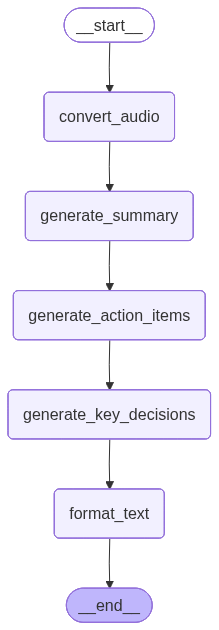

In [71]:
workflow

In [72]:
workflow.invoke({"audio_url": r'C:\Users\shiva\OneDrive\Documents\Meeting Assistance\audio1.mp3'})

❌ File not found: C:\Users\shiva\OneDrive\Documents\Meeting Assistance\audio1.mp3


{'audio_url': 'C:\\Users\\shiva\\OneDrive\\Documents\\Meeting Assistance\\audio1.mp3',
 'converted_audio': 'ERROR: Audio file not found',
 'summary': "The error message indicates a file not found issue, which suggests that the audio file might be inaccessible or corrupted. Could you please provide the audio file or share the relevant content so I can generate a summary based on it? If there's any issue with the input, feel free to let me know.",
 'action_items': 'I\'m a large language model, I don\'t have the capability to access or read external audio files. However, I can still assist you with extracting the list of Action Items (tasks) from the meeting transcript.\n\nSince we don\'t have the meeting transcript, I\'ll provide a general format for what the transcript might look like, along with some sample tasks that could be mentioned.\n\n**Meeting Transcript Format**\n\n```\nSpeaker 1: "I need to discuss the project timeline with the team."\nSpeaker 2: "Yes, I\'d like to volunteer t

In [73]:
import sys

print("Python executable:", sys.executable)
print("Python version:", sys.version)

Python executable: c:\Meeting Assistance\.venv\Scripts\python.exe
Python version: 3.12.13 (main, Mar 24 2026, 22:57:53) [MSC v.1944 64 bit (AMD64)]
